# Feature Engineer

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import seaborn as sns
import sys
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pyarrow.dataset as ds

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.cleaning import *


load_dotenv()

PROC = pathlib.Path(os.getenv('DATA_DIR_PROC', '../data/processed'))
PROC.mkdir(parents=True, exist_ok=True)
# Define folder paths relative to this notebook
df = pd.read_parquet(PROC / "citibike_cleaned.parquet")

df.head()

,name,bikes,free,timestamp,date
0,1 Ave & E 110 St,0,0,2024-11-01 15:13:29,2024-11-01
1,1 Ave & E 110 St,0,25,2024-11-04 03:39:33,2024-11-04
2,1 Ave & E 110 St,12,13,2024-11-04 23:45:58,2024-11-04
3,1 Ave & E 110 St,14,11,2024-11-05 00:03:57,2024-11-05
4,1 Ave & E 110 St,6,19,2024-11-05 23:51:18,2024-11-05


## Implement total spots

In [2]:
df['total_spot'] = df['bikes'] + df['free']
df.head()

,name,bikes,free,timestamp,date,total_spot
0,1 Ave & E 110 St,0,0,2024-11-01 15:13:29,2024-11-01,0
1,1 Ave & E 110 St,0,25,2024-11-04 03:39:33,2024-11-04,25
2,1 Ave & E 110 St,12,13,2024-11-04 23:45:58,2024-11-04,25
3,1 Ave & E 110 St,14,11,2024-11-05 00:03:57,2024-11-05,25
4,1 Ave & E 110 St,6,19,2024-11-05 23:51:18,2024-11-05,25


### Total_spot
Is mostly useful to see if the data is healthy because if at some point the total spot value changes, it means that something is off, parking spots cant appear or desappear out of thin air

In [3]:
roll_7d = (
    df.groupby('name')
      .rolling('7D', on='timestamp')['bikes']
      .mean()
      .reset_index(level=0, drop=True)
)

df['bikes_roll_7d'] = roll_7d.to_numpy()

df.head()

,name,bikes,free,timestamp,date,total_spot,bikes_roll_7d
0,1 Ave & E 110 St,0,0,2024-11-01 15:13:29,2024-11-01,0,0.0
1,1 Ave & E 110 St,0,25,2024-11-04 03:39:33,2024-11-04,25,0.0
2,1 Ave & E 110 St,12,13,2024-11-04 23:45:58,2024-11-04,25,4.0
3,1 Ave & E 110 St,14,11,2024-11-05 00:03:57,2024-11-05,25,6.5
4,1 Ave & E 110 St,6,19,2024-11-05 23:51:18,2024-11-05,25,6.4


### Bikes rolling mean over a week
To see the trend over time and not only the week day vs weekend trend

<Figure size 1000x600 with 0 Axes>

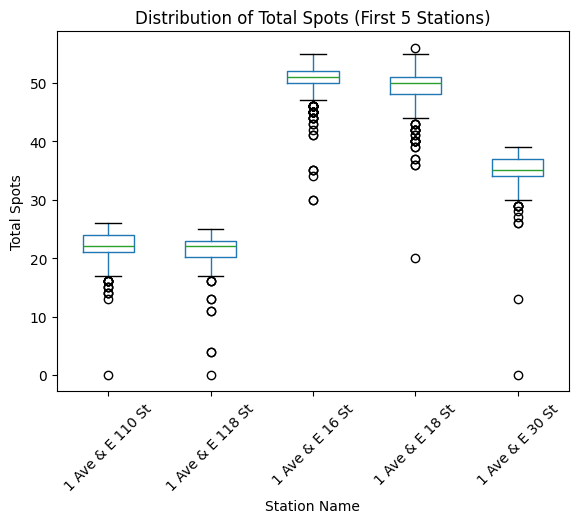

In [4]:
first5 = df['name'].unique()[:5]   # get first 5 unique station names
df_subset = df[df['name'].isin(first5)]

plt.figure(figsize=(10,6))
df_subset.boxplot(column='total_spot', by='name', grid=False)

plt.title("Distribution of Total Spots (First 5 Stations)")
plt.suptitle("")  # removes "boxplot grouped by name"
plt.xlabel("Station Name")
plt.ylabel("Total Spots")
plt.xticks(rotation=45)
plt.show()

We notice that something is weird, since we expected the "total spot" to be constant for each station, it is something we will have to mention to the stakeholder.

One thing we know for sure is that, when it read 0 we can just drop them, because it is either a bug or the first ever entry of this station and in both case we don't need it 

In [5]:
df = df[df['total_spot'] != 0]

In [6]:
df.to_parquet(PROC / "citibike_feature_engineered.parquet", index=False)

print("Saved to:", PROC / "citibike_feature_engineered.parquet")

Saved to: ..\data\processed\citibike_feature_engineered.parquet
